In [1]:
/env/bin/python -m pip install pymannkendall 

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose


from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

In [8]:
csv_path = "178.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df["TIME"] = pd.to_datetime(df["TIME"])          # convert to datetime
df = df.set_index("TIME")                        # set TIME as index

pv = df.PV.resample('MS').mean().interpolate(method='cubic')    #ACTION: Change the component you are analysing

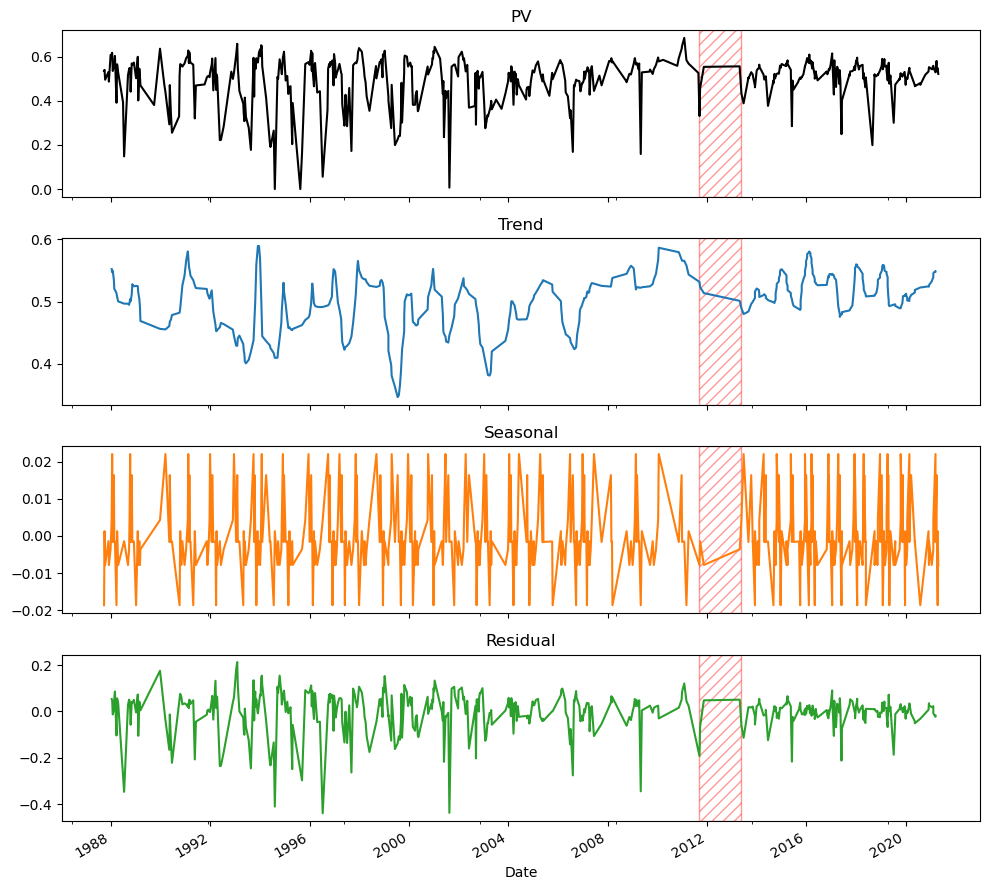

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from statsmodels.tsa.seasonal import seasonal_decompose

def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period
    (https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data)
    and periods with an observation density of less than four observations within a
    twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

df = df.reset_index(drop=True)
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable
pv = df.set_index("TIME")["PV"].astype(float)                 #ACTION: Change the component you are analysing

# Identify low-quality ranges based on off_value == 100
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    # Group consecutive low-quality periods
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="PV", color="black")                #ACTION: Change the component you are analysing
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

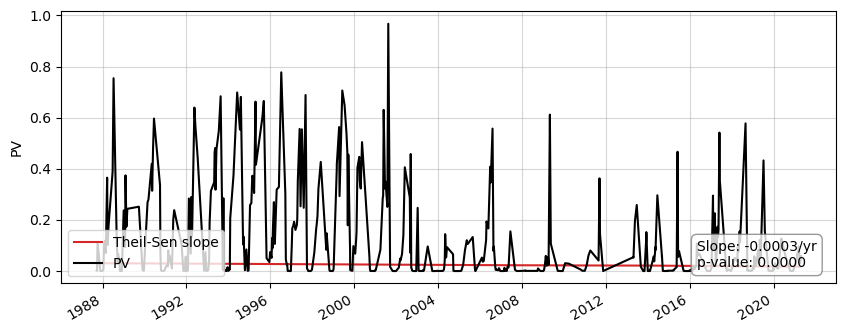

In [10]:
def mk_with_slopes(y, alpha = 0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    This was modified from the "pymannkendall" library to return fewer statistics which makes
    it a little more robust.
    
    Input:
        x: a vector (list, numpy array or pandas series) data
        alpha: significance level (0.05 default)
    Output:
        p: p-value of the significance test
        slope: Theil-Sen estimator/slope
        intercept: intercept of Kendall-Theil Robust Line
        
    """
    res = namedtuple('Mann_Kendall_Test', ['p','slope','intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method = 'skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# slope, intercept, lo_slope, up_slope = theilslopes(y, x, 0.95)
p, slope, intercept = mk_with_slopes(pv)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

y = range(0, len(pv)) * slope + intercept
ax.plot(date2num(pv.index), y, color='tab:red', label='Theil-Sen slope');

pv.plot(ax=ax, label='PV', color="black")
ax.set_ylabel('PV')
ax.set_xlabel(None)
ax.grid(alpha=0.5);

# Annotate slope and p-value as nice text box
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left');

In [11]:
def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period: https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data
    and periods with an observation density of less than four observations within a twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.

    Last modified: July 2023

    Parameters
    ----------
    df : pandas DataFrame with columns including:
    ['date']

    Returns
    -------
    df : pandas DataFrame with additional column:
    ['off_value']

    """

    # default: all data points are good
    df.loc[:, "off_value"] = 0

    # Add the first no-data times (SLC-off only)
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)

    df.loc[
        df[(df["date"] >= LS5_8_gap_start) & (df["date"] <= LS5_8_gap_end)].index,
        "off_value",
    ] = 100

    # periods with an observation density of less than four observations within a twelve month (365 days) period
    for i in range(3, len(df) - 3):
        # can change to another threshold (like: 100 days) to test dynamic no-data-period display
        if ((df.loc[i + 3, "date"] - df.loc[i, "date"]).days) > 365:
            df.loc[
                df[(df["date"] >= df.loc[i, "date"]) & (df["date"] <= df.loc[i + 3, "date"])].index,
                "off_value",
            ] = 100

    return df

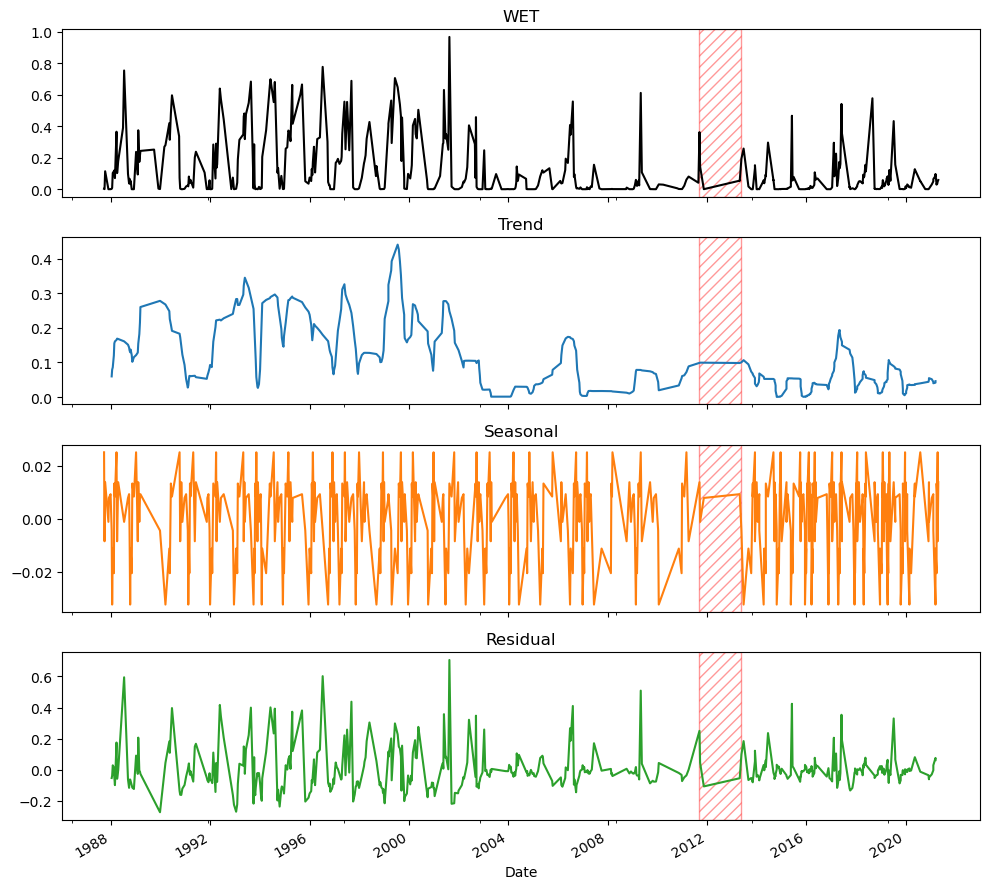

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from statsmodels.tsa.seasonal import seasonal_decompose

def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period
    (https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data)
    and periods with an observation density of less than four observations within a
    twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

df = df.reset_index()
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable
pv = df.set_index("TIME")["WET"].astype(float)

# Identify low-quality ranges based on off_value == 100
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    # Group consecutive low-quality periods
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="WET", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()